In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path

DATA_DIR = 'data'
OUT_DIR = Path('outputs/proposal_eda')
OUT_DIR.mkdir(parents=True, exist_ok=True)
TARGET_YEAR = 2015
EMP_YEAR = 2017

In [2]:
CODE_RE = re.compile(r'^\s*(?:w\d+:[\w_]+:)?\d+\s+')

def strip_code(v):
    if isinstance(v, str):
        return CODE_RE.sub('', v.strip()).strip()
    return v

def is_year(v):
    try:
        x = float(v)
    except (TypeError, ValueError):
        return False
    return not pd.isna(x) and 1900 <= x <= 2100 and float(int(x)) == x

def region_col(df):
    for c in df.columns:
        if 'ОКАТО' in str(c):
            return c

def is_aggregate(name):
    if not isinstance(name, str):
        return False
    if name == 'Российская Федерация':
        return True
    nl = name.lower()
    return 'федеральн' in nl and 'окру' in nl

PARTIAL = ('без АО', 'без данных', '(кроме', 'без Ханты', 'без Ненец')
def is_partial(name):
    return isinstance(name, str) and any(p in name for p in PARTIAL)

REGION_RENAME = {
    'г. Москва': 'Москва',
    'Город Москва столица Российской Федерации город федерального значения': 'Москва',
    'г. Санкт-Петербург': 'Санкт-Петербург',
    'Город Санкт-Петербург город федерального значения': 'Санкт-Петербург',
    'г. Севастополь': 'Севастополь',
    'Город федерального значения Севастополь': 'Севастополь',
    'Кемеровская область - Кузбасс': 'Кемеровская область',
    'Республика Адыгея (Адыгея)': 'Республика Адыгея',
    'Республика Северная Осетия-Алания': 'Республика Северная Осетия - Алания',
}
def normalize_region(n):
    return REGION_RENAME.get(n, n)

In [3]:
def parse_fedstat(path):
    raw = pd.read_excel(path, sheet_name='Данные', header=None)
    header = list(raw.iloc[2].tolist())
    # auto-name blank dim columns (data 14 and 15)
    for i, h in enumerate(header):
        if pd.isna(h):
            sample = raw.iloc[3:23, i].dropna().astype(str).str.strip().tolist()
            text = ' '.join(sample).upper()
            if any(k in text for k in ('РОССИЙСКАЯ', 'ОБЛАСТ', 'РЕСПУБЛИКА', 'КРАЙ', 'АВТОНОМНЫЙ', 'ОКРУГ')):
                header[i] = 'Классификатор объектов административно-территориального деления (ОКАТО)'
            elif any(k in text for k in ('РАЗДЕЛ', 'ДОБЫЧА', 'ОБРАБАТЫВ', 'ВОДОСНАБЖ', 'СТРОИТЕЛЬ')):
                header[i] = 'Классификатор видов экономической деятельности (ОКВЭД2)'
            else:
                header[i] = 'Единица измерения'
    data = raw.iloc[3:].copy()
    data.columns = header
    data = data.dropna(how='all')
    year_cols = [c for c in data.columns if is_year(c)]
    dim_cols = [c for c in data.columns if not is_year(c)]
    for c in dim_cols:
        data[c] = data[c].apply(strip_code)
    df = data.melt(id_vars=dim_cols, value_vars=year_cols, var_name='Год', value_name='Значение')
    df['Год'] = df['Год'].astype(float).astype(int)
    df['Значение'] = pd.to_numeric(df['Значение'], errors='coerce')
    return df.dropna(subset=['Значение']).reset_index(drop=True)

In [4]:
files = sorted(f for f in os.listdir(DATA_DIR) if f.endswith('.xls'))
datasets = {f: parse_fedstat(os.path.join(DATA_DIR, f)) for f in files}
print(f'loaded {len(datasets)} files')
for f in files:
    print(f'  {f}: {datasets[f].shape}')

loaded 13 files
  01.xls: (1839, 5)
  02.xls: (1324471, 7)
  data (10).xls: (2400, 5)
  data (11).xls: (8259, 6)
  data (12).xls: (1493, 5)
  data (13).xls: (29044, 7)
  data (14).xls: (2400, 4)
  data (15).xls: (4320, 4)
  data (5).xls: (3503, 5)
  data (6).xls: (10449, 6)
  data (7).xls: (18951, 6)
  data (8).xls: (1493, 5)
  data (9).xls: (87627, 8)


In [5]:
def prepare(file, var_name, filter_fn=None, agg_fn=None, year=TARGET_YEAR):
    df = datasets[file].copy()
    rc = region_col(df)
    if filter_fn is not None:
        df = filter_fn(df)
    df = df[df['Год'] == year]
    df[rc] = df[rc].map(normalize_region)
    df = df[~df[rc].map(is_aggregate)]
    df = df[~df[rc].map(is_partial)]
    if agg_fn is not None:
        df = agg_fn(df, rc)
    out = df.rename(columns={rc: 'region', 'Значение': var_name, 'Год': 'year'})
    return out[['region', 'year', var_name]].reset_index(drop=True)

In [6]:
WAL = 'Всего в трудоспособном возрасте (для мужчин 16-59,для женщин 16-54)'

parts = {}
parts['life_expectancy'] = prepare('data (13).xls', 'life_expectancy',
    lambda d: d[(d['Структура населения']=='Оба пола') & (d['Тип поселения']=='все население')])
parts['visits_per_capita'] = prepare('01.xls', 'visits_per_capita')
parts['urban_share'] = prepare('data (5).xls', 'urban_share')
parts['population_avg'] = prepare('data (6).xls', 'population_avg',
    lambda d: d[d['Тип поселения']=='все население'])
parts['grp_total'] = prepare('data (7).xls', 'grp_total',
    lambda d: d[d['Классификатор видов экономической деятельности (ОКВЭД)']=='Всего'])
parts['age_struct_share'] = prepare('data (9).xls', 'age_struct_share',
    lambda d: d[(d['Возраст']==WAL) & (d['Структура населения']=='Всего') & (d['Тип поселения']=='Всего')])
parts['emissions_h1'] = prepare('data (12).xls', 'emissions_h1')
parts['emissions_fuel'] = prepare('data (11).xls', 'emissions_fuel',
    agg_fn=lambda d, rc: d.groupby([rc, 'Год'], as_index=False)['Значение'].sum())
parts['industrial_index'] = prepare('data (10).xls', 'industrial_index')

for k, v in parts.items():
    print(f'{k}: {v.shape}')

life_expectancy: (85, 3)
visits_per_capita: (83, 3)
urban_share: (85, 3)
population_avg: (85, 3)
grp_total: (85, 3)
age_struct_share: (85, 3)
emissions_h1: (85, 3)
emissions_fuel: (85, 3)
industrial_index: (85, 3)


In [7]:
# data (14) is identical to data (10) — verify and skip
d10 = datasets['data (10).xls']; d14 = datasets['data (14).xls']
rc10 = region_col(d10); rc14 = region_col(d14)
m10 = d10[[rc10, 'Год', 'Значение']].rename(columns={rc10: 'r', 'Значение': 'v10'})
m14 = d14[[rc14, 'Год', 'Значение']].rename(columns={rc14: 'r', 'Значение': 'v14'})
m = m10.merge(m14, on=['r', 'Год'])
print('data (14) vs data (10) max abs diff:', (m['v10'] - m['v14']).abs().max())

data (14) vs data (10) max abs diff: 0.0


In [8]:
order = ['population_avg','life_expectancy','visits_per_capita','urban_share','grp_total',
         'age_struct_share','emissions_h1','emissions_fuel','industrial_index']
merged = parts[order[0]].copy()
for v in order[1:]:
    merged = merged.merge(parts[v], on=['region', 'year'], how='outer')
print('merged shape:', merged.shape)

merged shape: (85, 11)


In [9]:
merged['grp_pc'] = merged['grp_total'] / merged['population_avg']
merged['emissions_h1_pc'] = merged['emissions_h1'] / merged['population_avg']
merged['emissions_fuel_pc'] = merged['emissions_fuel'] / merged['population_avg']
merged.to_csv('merged_dataset_2015.csv', index=False)
print('saved merged_dataset_2015.csv', merged.shape)

saved merged_dataset_2015.csv (85, 14)


In [10]:
val = merged.copy()
val['ln_grp_pc'] = np.log(val['grp_pc'])
val['ln_emissions_h1_pc'] = np.log(val['emissions_h1_pc'])
val['ln_emissions_fuel_pc'] = np.log(val['emissions_fuel_pc'])
val['ln_population_avg'] = np.log(val['population_avg'])
val.to_csv('validated_dataset_2015.csv', index=False)
print('saved validated_dataset_2015.csv', val.shape)

saved validated_dataset_2015.csv (85, 18)


In [11]:
SECTORS = {
    'emp_mining': 'ДОБЫЧА ПОЛЕЗНЫХ ИСКОПАЕМЫХ',
    'emp_manufacturing': 'ОБРАБАТЫВАЮЩИЕ ПРОИЗВОДСТВА',
    'emp_energy': 'ОБЕСПЕЧЕНИЕ ЭЛЕКТРИЧЕСКОЙ ЭНЕРГИЕЙ, ГАЗОМ И ПАРОМ; КОНДИЦИОНИРОВАНИЕ ВОЗДУХА',
    'emp_metallurgy': 'Производство металлургическое',
    'emp_chemicals': 'Производство химических веществ и химических продуктов',
    'emp_construction': 'СТРОИТЕЛЬСТВО',
}

d15 = datasets['data (15).xls']
rc15 = region_col(d15)
sc = 'Классификатор видов экономической деятельности (ОКВЭД2)'
sub = d15[d15['Год'] == EMP_YEAR].copy()
sub[rc15] = sub[rc15].map(normalize_region)
sub = sub[~sub[rc15].map(is_aggregate)]
sub = sub[~sub[rc15].map(is_partial)]
wide = sub.pivot_table(index=rc15, columns=sc, values='Значение', aggfunc='first').reset_index()
wide = wide.rename(columns={rc15: 'region'})

emp = wide[['region']].copy()
for short, long in SECTORS.items():
    emp[short] = wide[long]

ext = val.merge(emp, on='region', how='left')
for s in SECTORS:
    ext[f'{s}_pc'] = ext[s] / ext['population_avg']
for s in ['emp_mining', 'emp_manufacturing', 'emp_energy', 'emp_construction']:
    pc = f'{s}_pc'
    if (ext[pc] > 0).all():
        ext[f'ln_{s}_pc'] = np.log(ext[pc])

ext.to_csv('validated_dataset_extended.csv', index=False)
print('saved validated_dataset_extended.csv', ext.shape)

saved validated_dataset_extended.csv (85, 34)


In [12]:
DV = 'life_expectancy'
ENDO = 'ln_emissions_h1_pc'
IV = 'ln_emp_mining_pc'
CONTROLS = ['ln_grp_pc', 'urban_share', 'age_struct_share', 'ln_population_avg']
MAIN_VARS = [DV, ENDO, IV] + CONTROLS

print('shape:', ext.shape)
print('duplicated regions:', ext['region'].duplicated().sum())
print('missing in main vars:')
print(ext[MAIN_VARS].isna().sum().to_string())
for c in MAIN_VARS:
    if c.startswith('ln_'):
        print(f'non-finite in {c}:', int((~np.isfinite(ext[c])).sum()))

shape: (85, 34)
duplicated regions: 0
missing in main vars:
life_expectancy       0
ln_emissions_h1_pc    0
ln_emp_mining_pc      0
ln_grp_pc             0
urban_share           0
age_struct_share      0
ln_population_avg     0
non-finite in ln_emissions_h1_pc: 0
non-finite in ln_emp_mining_pc: 0
non-finite in ln_grp_pc: 0
non-finite in ln_population_avg: 0


In [13]:
desc = ext[MAIN_VARS].agg(['mean', 'std', 'min', 'median', 'max']).T.round(4)
desc.to_csv(OUT_DIR / '06_descriptive_statistics.csv')
desc.to_excel(OUT_DIR / '06_descriptive_statistics.xlsx')
print(desc)

                       mean      std      min   median       max
life_expectancy     70.5662   2.3977  63.1400  70.3900   78.4700
ln_emissions_h1_pc -10.3097   1.4159 -14.5157 -10.2621   -6.9957
ln_emp_mining_pc    -5.5818   1.6311  -8.7341  -5.9033   -1.5898
ln_grp_pc            5.8500   0.6917   4.6834   5.7689    8.5867
urban_share         70.2682  13.2684  29.9000  71.4000  100.0000
age_struct_share    58.2165   2.0328  54.2000  57.7000   64.9000
ln_population_avg   13.9713   0.9782  10.6546  13.9885   16.3233


In [14]:
corr = ext[MAIN_VARS].corr().round(3)
print(corr)

                    life_expectancy  ln_emissions_h1_pc  ln_emp_mining_pc  \
life_expectancy               1.000              -0.517            -0.336   
ln_emissions_h1_pc           -0.517               1.000             0.650   
ln_emp_mining_pc             -0.336               0.650             1.000   
ln_grp_pc                    -0.127               0.673             0.629   
urban_share                  -0.146               0.362             0.200   
age_struct_share              0.100               0.225             0.448   
ln_population_avg             0.422              -0.155            -0.282   

                    ln_grp_pc  urban_share  age_struct_share  \
life_expectancy        -0.127       -0.146             0.100   
ln_emissions_h1_pc      0.673        0.362             0.225   
ln_emp_mining_pc        0.629        0.200             0.448   
ln_grp_pc               1.000        0.536             0.499   
urban_share             0.536        1.000             0.278   

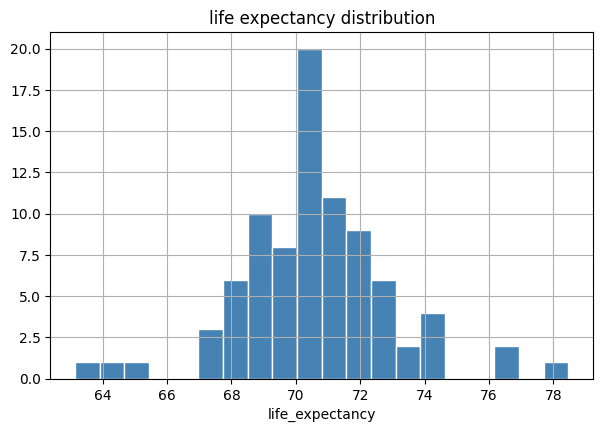

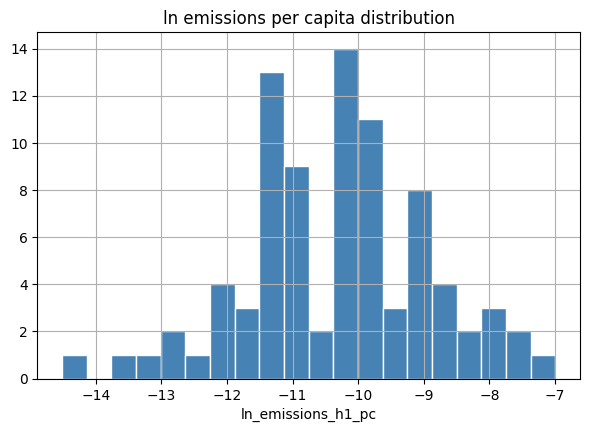

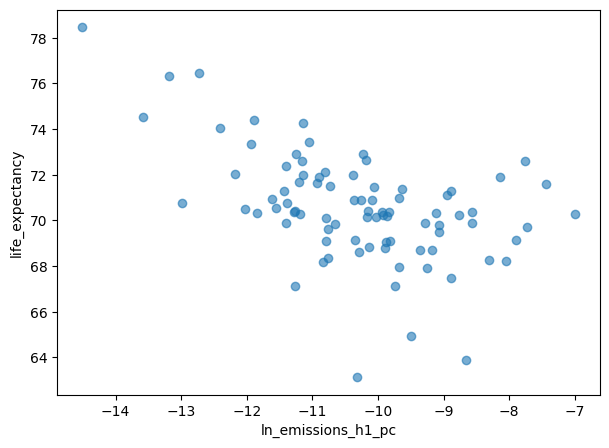

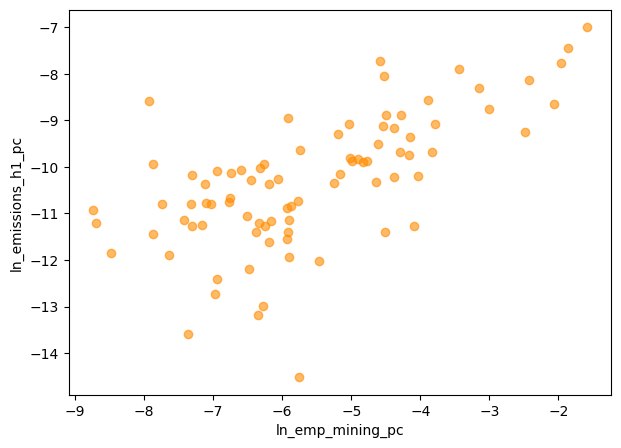

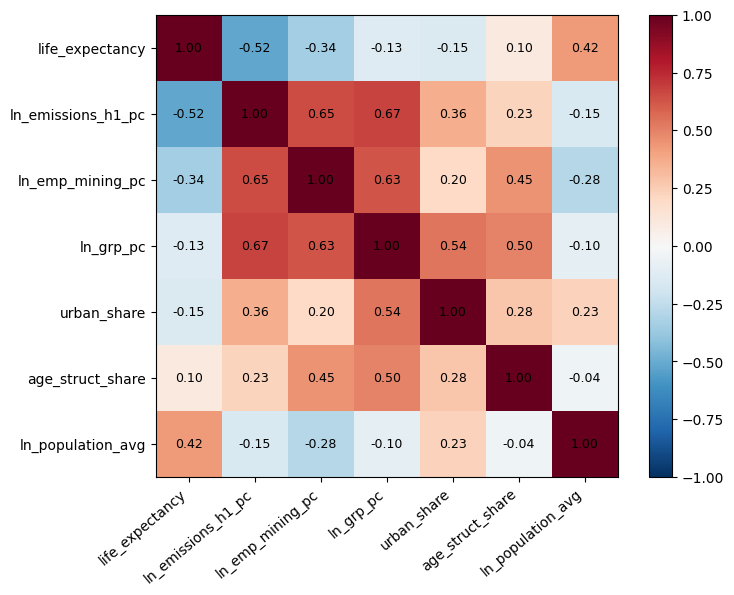

saved figures to outputs/proposal_eda


In [15]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ext['life_expectancy'].hist(ax=ax, bins=20, color='steelblue', edgecolor='white')
ax.set_xlabel('life_expectancy'); ax.set_title('life expectancy distribution')
fig.savefig(OUT_DIR / '01_life_expectancy_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
ext['ln_emissions_h1_pc'].hist(ax=ax, bins=20, color='steelblue', edgecolor='white')
ax.set_xlabel('ln_emissions_h1_pc'); ax.set_title('ln emissions per capita distribution')
fig.savefig(OUT_DIR / '02_emissions_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(ext['ln_emissions_h1_pc'], ext['life_expectancy'], alpha=0.6)
ax.set_xlabel('ln_emissions_h1_pc'); ax.set_ylabel('life_expectancy')
fig.savefig(OUT_DIR / '03_life_expectancy_vs_emissions.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(ext['ln_emp_mining_pc'], ext['ln_emissions_h1_pc'], alpha=0.6, color='darkorange')
ax.set_xlabel('ln_emp_mining_pc'); ax.set_ylabel('ln_emissions_h1_pc')
fig.savefig(OUT_DIR / '04_emissions_vs_mining_instrument.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=40, ha='right')
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center', fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.04)
fig.savefig(OUT_DIR / '05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('saved figures to', OUT_DIR)

In [16]:
X = sm.add_constant(ext[[IV] + CONTROLS])
fs = sm.OLS(ext[ENDO], X).fit(cov_type='HC1')
F = float(fs.f_test(f'{IV} = 0').fvalue)
print(f'first-stage: coef={fs.params[IV]:+.4f}, t={fs.tvalues[IV]:+.2f}, '
      f'p={fs.pvalues[IV]:.4f}, R2={fs.rsquared:.4f}, F={F:.2f}')

first-stage: coef=+0.3838, t=+3.68, p=0.0002, R2=0.5794, F=13.54


In [17]:
X = sm.add_constant(ext[[ENDO] + CONTROLS])
ols = sm.OLS(ext[DV], X).fit(cov_type='HC1')
print(ols.summary().tables[1])
print(f'OLS R2 = {ols.rsquared:.4f}')

                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 29.7128      7.630      3.894      0.000      14.759      44.667
ln_emissions_h1_pc    -1.1736      0.202     -5.818      0.000      -1.569      -0.778
ln_grp_pc              1.6372      0.627      2.610      0.009       0.408       2.866
urban_share           -0.0503      0.015     -3.317      0.001      -0.080      -0.021
age_struct_share       0.1371      0.153      0.898      0.369      -0.162       0.436
ln_population_avg      1.0541      0.262      4.025      0.000       0.541       1.567
OLS R2 = 0.5314


In [18]:
try:
    from linearmodels.iv import IV2SLS as LM_IV2SLS
    iv = LM_IV2SLS(ext[DV], sm.add_constant(ext[CONTROLS]), ext[[ENDO]], ext[[IV]]).fit(cov_type='robust')
    print(iv.summary)
except ImportError:
    from statsmodels.sandbox.regression.gmm import IV2SLS
    endog = sm.add_constant(ext[[ENDO] + CONTROLS])
    instr = sm.add_constant(ext[[IV] + CONTROLS])
    iv = IV2SLS(ext[DV], endog, instr).fit()
    print(iv.summary().tables[1])
    print(f'2SLS R2 = {iv.rsquared:.4f}')

                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 24.9434      7.938      3.142      0.002       9.144      40.743
ln_emissions_h1_pc    -1.6006      0.423     -3.786      0.000      -2.442      -0.759
ln_grp_pc              2.2596      0.721      3.134      0.002       0.825       3.694
urban_share           -0.0483      0.018     -2.649      0.010      -0.085      -0.012
age_struct_share       0.0934      0.117      0.800      0.426      -0.139       0.326
ln_population_avg      0.9917      0.217      4.563      0.000       0.559       1.424
2SLS R2 = 0.4982
